In [ ]:
%pip install pandas matplotlib seaborn scikit-learn


In [1]:

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/housing-dataset/Housing.csv


In [2]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

In [3]:
df = pd.read_csv('/kaggle/input/housing-dataset/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
print('shape of data is', df.shape)
print(f"Total Data size is {df.shape[0]}")
print(f"Total number of features in data are {df.shape[1]}")

shape of data is (545, 13)
,Total Data size is 545
,Total number of features in data are 13


In [5]:
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 545 entries, 0 to 544
,Data columns (total 13 columns):
, #   Column            Non-Null Count  Dtype 
,---  ------            --------------  ----- 
, 0   price             545 non-null    int64 
, 1   area              545 non-null    int64 
, 2   bedrooms          545 non-null    int64 
, 3   bathrooms         545 non-null    int64 
, 4   stories           545 non-null    int64 
, 5   mainroad          545 non-null    object
, 6   guestroom         545 non-null    object
, 7   basement          545 non-null    object
, 8   hotwaterheating   545 non-null    object
, 9   airconditioning   545 non-null    object
, 10  parking           545 non-null    int64 
, 11  prefarea          545 non-null    object
, 12  furnishingstatus  545 non-null    object
,dtypes: int64(6), object(7)
,memory usage: 55.5+ KB


In [7]:
df.isnull().sum().to_frame().rename(columns={0: 'No. of null entries'})

,No. of null entries
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [8]:
print(f"The duplicated values in dataframe are {df.duplicated().sum()}")

The duplicated values in dataframe are 0


In [9]:
def target_variable_visualization(tar_col):
    plt.figure(figsize=(10, 6))

    plt.subplot(1,2,1)
    sns.distplot(df[tar_col], color='red')
    plt.xlabel(tar_col)
    plt.ylabel('Density')
    plt.title('Price Distribution of Houses', pad=20, fontweight='black', fontdict={'fontsize': 10, 'color': 'blue'})

    plt.subplot(1,2,2)
    sns.boxplot(df, y=tar_col, palette='dark:salmon_r')
    plt.xlabel('Price of Houses')
    plt.xlabel('Price of Houses')
    plt.title('Price Spreadness of Houses', pad=20, fontweight='black', fontdict={'fontsize': 10, 'color': 'blue'})

    plt.show()
    plt.tight_layout()

In [10]:
def categorical_variable_visualization(col):
    plt.figure(figsize=(15, 6))
    plt.subplot(1,3,1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='husl')
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel('Counts')

    plt.subplot(1,3,2)
    sns.boxplot(data=df, x=col, y='price', palette='husl')
    plt.title(f"Price Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('Price')

    plt.subplot(1,3,3)
    avg_df = df.groupby(col)['price'].mean().round(2).to_frame()
    sns.barplot(data=avg_df, x=avg_df.index, y='price', palette='husl')
    plt.title(f"Price Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('Price')

    plt.show()
    plt.tight_layout()

In [11]:
def numerical_variable_visualization(cols):
    plt.figure(figsize=(15, 6))
    n=len(cols)
    i=1
    for col in cols:
        plt.subplot(1,n,i)
        sns.regplot(data=df, y='price', x=col, scatter_kws={'color': 'red'}, line_kws={'color': 'blue'}, marker='o')
        plt.title(f"Price Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel('Price')
        i+=1

    plt.show()
    plt.tight_layout()

In [12]:
tar_col = 'price'
numerical_variable= df.select_dtypes(include=['int64', 'float', 'number']).columns
categorical_variable=df.select_dtypes(include='object').columns

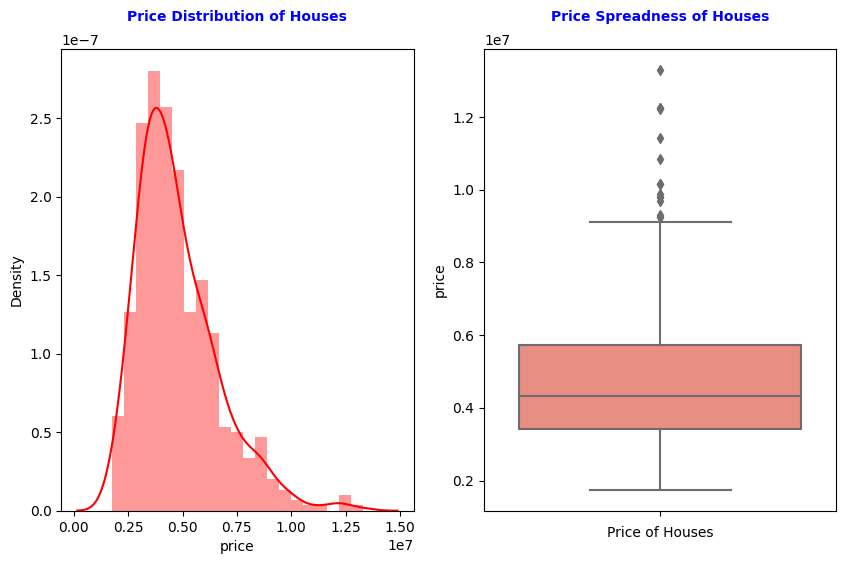

<Figure size 640x480 with 0 Axes>

In [13]:
target_variable_visualization('price')

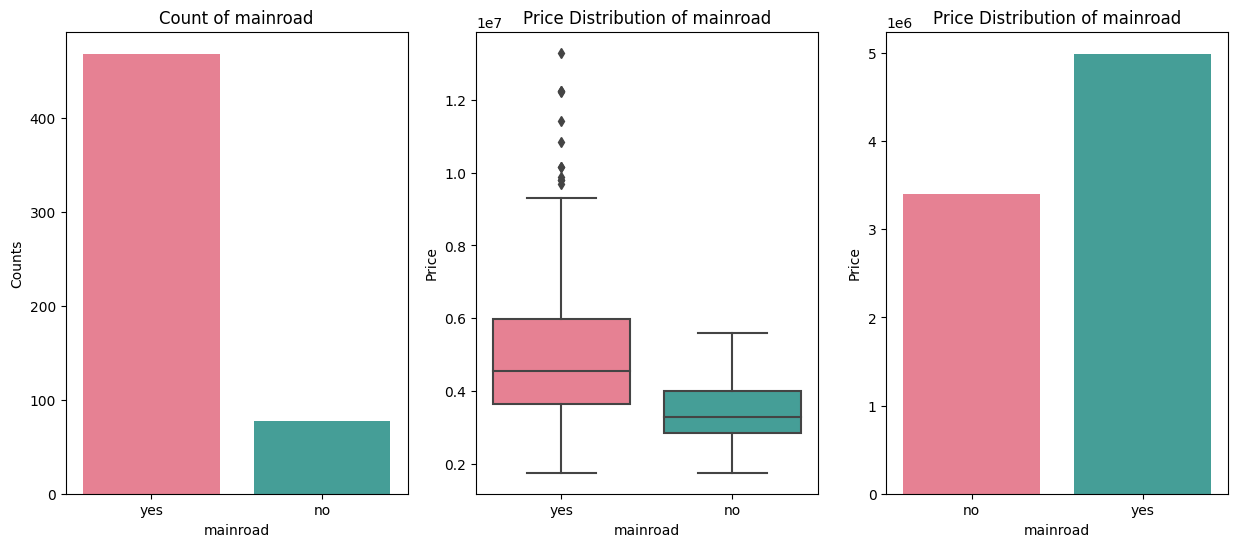

<Figure size 640x480 with 0 Axes>

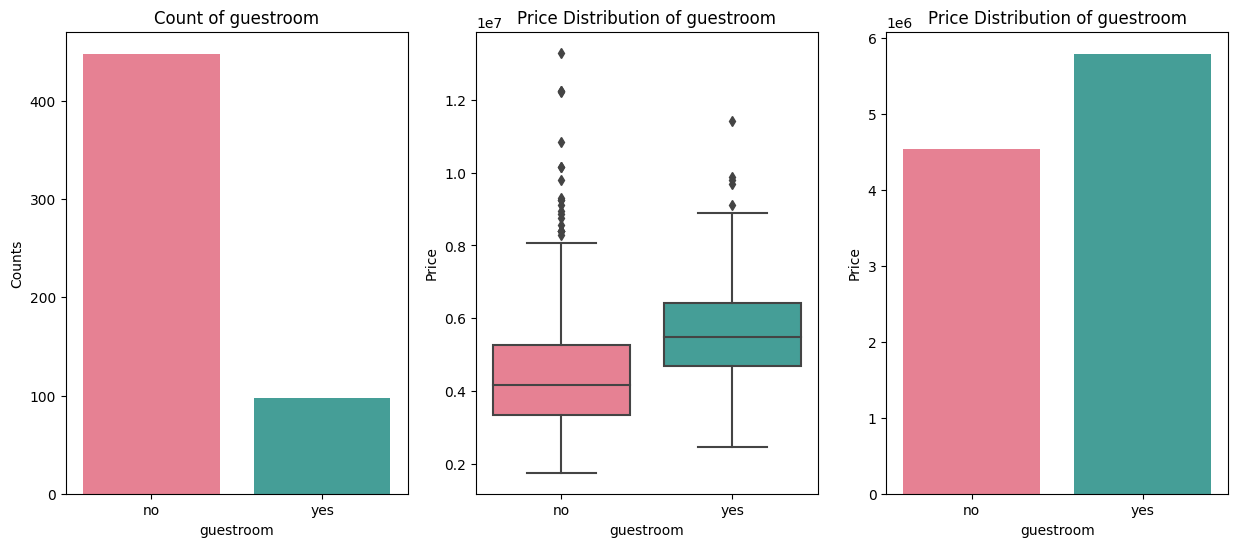

<Figure size 640x480 with 0 Axes>

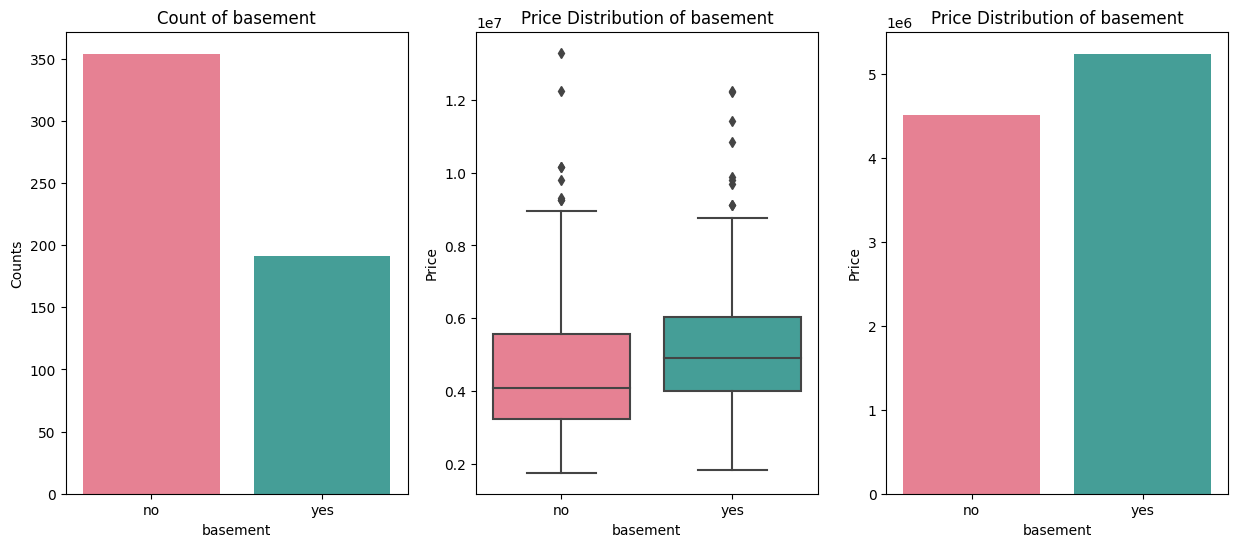

<Figure size 640x480 with 0 Axes>

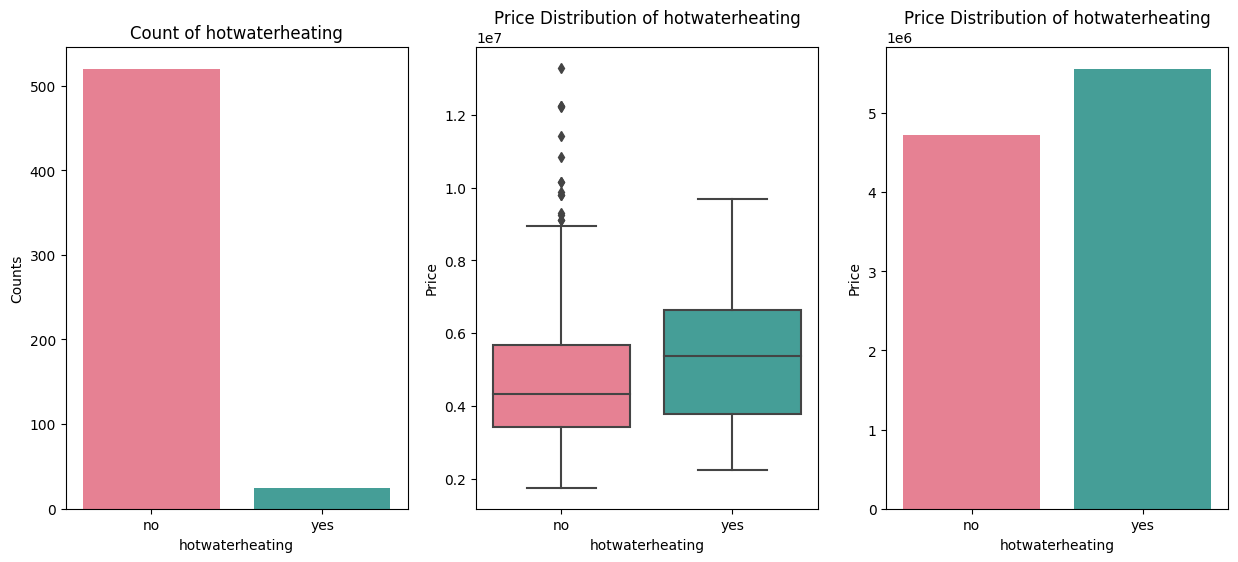

<Figure size 640x480 with 0 Axes>

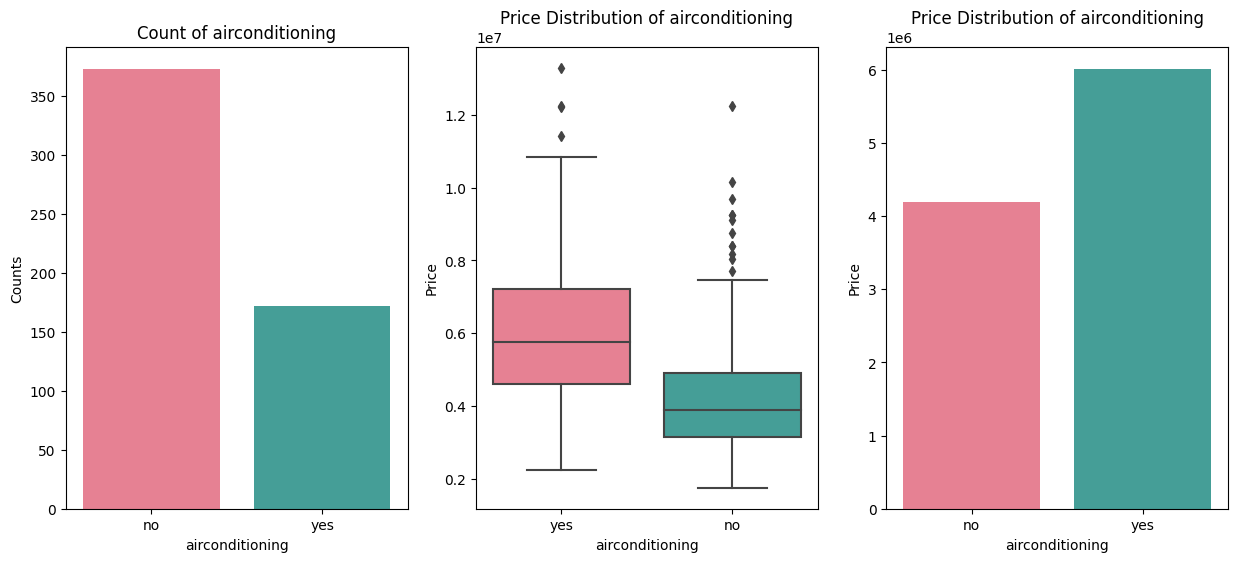

<Figure size 640x480 with 0 Axes>

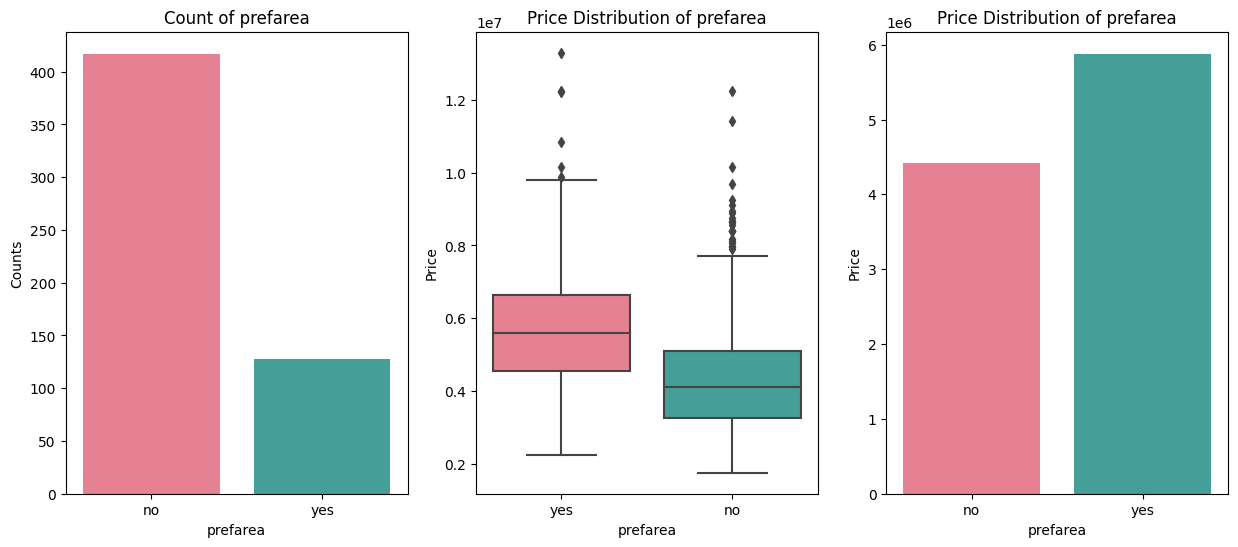

<Figure size 640x480 with 0 Axes>

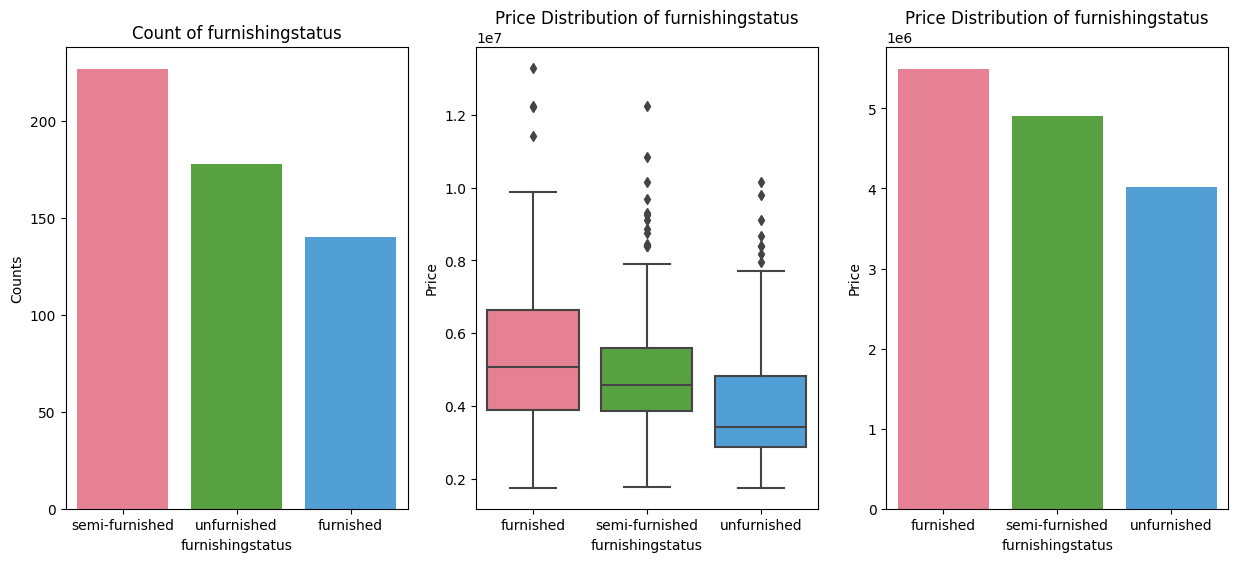

<Figure size 640x480 with 0 Axes>

In [14]:
for col in categorical_variable:
    categorical_variable_visualization(col)

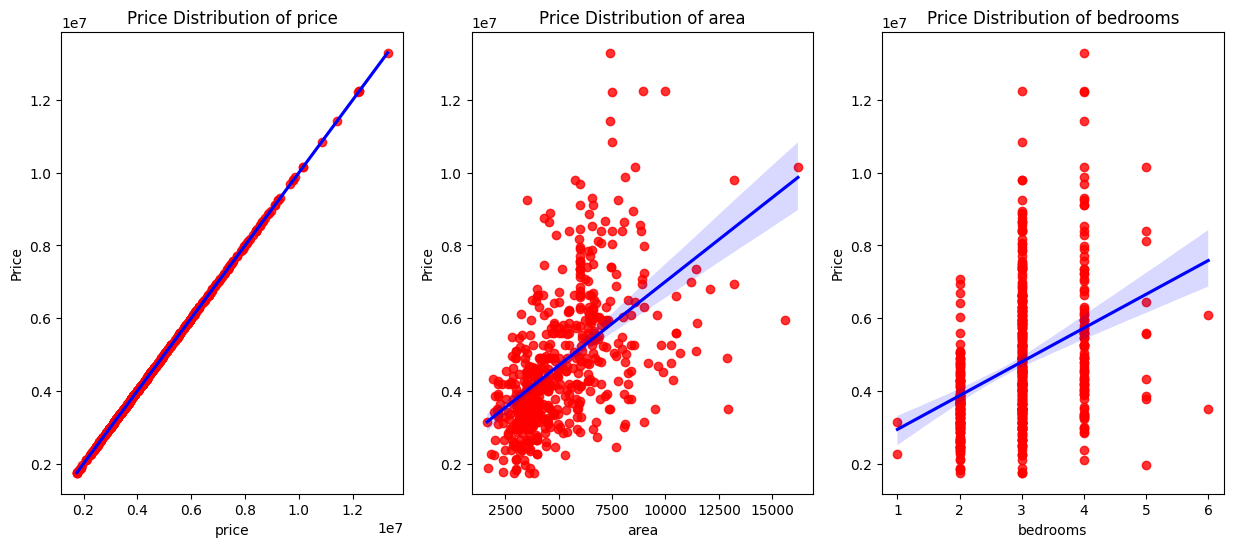

<Figure size 640x480 with 0 Axes>

In [15]:
numerical_variable_visualization(numerical_variable[:3])

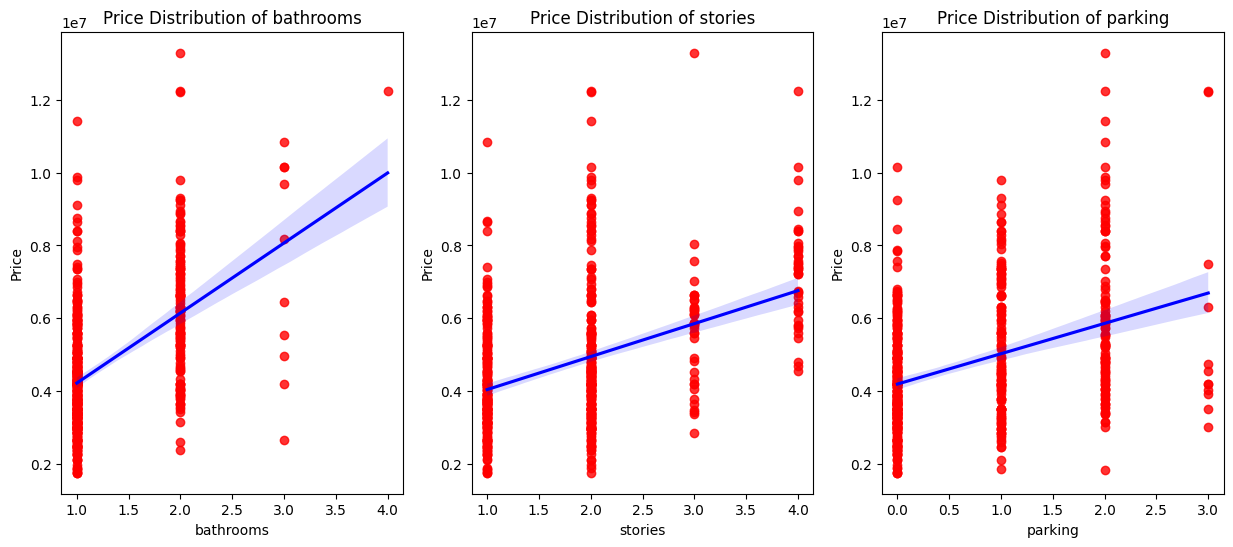

<Figure size 640x480 with 0 Axes>

In [16]:
numerical_variable_visualization(numerical_variable[3:])

In [17]:
X = df.drop(columns='price')
y=df[['price']]

In [18]:
sc = StandardScaler()

In [19]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [21]:
print(f"shape of trainning feature is {X_train.shape}")
print(f"shape of testing feature is {X_test.shape}")

shape of trainning feature is (436, 13)
,shape of testing feature is (109, 13)


In [22]:
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.fit_transform(X_test)

In [23]:
def error_metrics(y_train_true, y_train_pred, y_test_true, y_test_pred, model):

    errors = {}

    errors['Model'] = model
    
    errors['Train_MAE'] = mean_absolute_error(y_train_true, y_train_pred)
    errors['Train_MSE'] = mean_squared_error(y_train_true, y_train_pred)
    errors['Train_RMSE'] = np.sqrt(errors['Train_MSE'])
    errors['Train_R2_Score'] = r2_score(y_train_true, y_train_pred)

    errors['Test_MAE'] = mean_absolute_error(y_test_true, y_test_pred)
    errors['Test_MSE'] = mean_squared_error(y_test_true, y_test_pred)
    errors['Test_RMSE'] = np.sqrt(errors['Test_MSE'])
    errors['Test_R2_Score'] = r2_score(y_test_true, y_test_pred)

    return errors

In [24]:
model_evaluation = []

In [25]:
models = {
    'Linear Regression' : LinearRegression(),
    'Lasso': Lasso(),
    'Lasso CV': LassoCV(),
    'Ridge': Ridge(),
    'Ridge CV': RidgeCV(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'XG Boost': XGBRegressor(tree_method="hist",eval_metric=mean_absolute_error)
}

In [26]:
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_train_pred = model.predict(X_train_sc)
    y_test_pred = model.predict(X_test_sc)
    error_metrics_model = error_metrics(y_train, y_train_pred, y_test, y_test_pred, name)
    model_evaluation.append(error_metrics_model)

In [27]:
model_evaluation_df = pd.DataFrame(model_evaluation)
model_evaluation_df

,Model,Train_MAE,Train_MSE,Train_RMSE,Train_R2_Score,Test_MAE,Test_MSE,Test_RMSE,Test_R2_Score
0,Linear Regression,719242.893672,9.683582e+11,984051.923651,0.685944,9.625727e+05,1.808561e+12,1.344827e+06,0.642193
1,Lasso,719242.712838,9.683582e+11,984051.923655,0.685944,9.625729e+05,1.808562e+12,1.344828e+06,0.642193
2,Lasso CV,719074.487821,9.683658e+11,984055.781329,0.685941,9.627151e+05,1.810018e+12,1.345369e+06,0.641905
3,Ridge,719161.252431,9.683620e+11,984053.858949,0.685943,9.625578e+05,1.809323e+12,1.345111e+06,0.642042
4,Ridge CV,718618.998152,9.687211e+11,984236.314048,0.685826,9.625034e+05,1.816645e+12,1.347830e+06,0.640594
5,Decision Tree,8107.798165,4.500864e+09,67088.475405,0.998540,1.325989e+06,3.298963e+12,1.816305e+06,0.347331
6,Random Forest,279387.421865,1.591991e+11,398997.560264,0.948369,1.030969e+06,1.981462e+12,1.407644e+06,0.607986
7,Gradient Boosting,480893.468848,4.241081e+11,651235.857823,0.862454,1.002274e+06,1.897781e+12,1.377600e+06,0.624541
8,XG Boost,51109.270929,8.954928e+09,94630.483000,0.997096,1.630949e+06,4.773054e+12,2.184732e+06,0.055695
